# 🏆 Projeto Final - Camada Gold: Análise, Visualização e Dashboard
**Curso:** Análise de Dados com Python - SCtec  
**Aluno:** L. Felipe Martins  

Este Jupyter Notebook consolida a **Fase 3 (Camada Gold)** da nossa arquitetura de dados. 
Aqui realizamos:
1. Resolução das **7 Perguntas de Negócio** com exibições textuais e gráficas estáticas e defensivas.
2. Um **Dashboard Interativo Integrado (Tema Escuro - Estilo Power BI)** usando Plotly e `ipywidgets` para análise em tempo real.
3. Persistência da tabela física agregada `gold_resumo_orgaos` no PostgreSQL com confirmação transacional (`commit`).
4. Validação final lendo os dados de volta do banco de dados.

---
### ⚙️ 1. Gerenciamento Automatizado de Dependências e Carga de Dados

In [7]:
import sys
import subprocess

# Lista de dependências críticas para o ambiente interativo do Jupyter
dependencias = ["plotly", "ipywidgets", "nbformat"]
instalou = False

for lib in dependencias:
    try:
        __import__(lib)
    except ImportError:
        print(f"[*] Instalação automática da biblioteca ausente: {lib}...")
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", lib, "--break-system-packages"
        ])
        instalou = True

if instalou:
    print("[SUCCESS] Dependências instaladas! Por favor, reinicie o Kernel do Jupyter para carregar as alterações.")
else:
    print("[+] Todas as dependências necessárias estão presentes no ambiente!")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import ipywidgets as widgets
from ipywidgets import interact
import warnings
from banco import conectar, executar, inserir_em_lote

warnings.filterwarnings('ignore')

# Configurações estéticas para os gráficos estáticos do Matplotlib
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'figure.titlesize': 16,
    'text.color': 'black',
    'axes.labelcolor': 'black',
    'xtick.color': 'black',
    'ytick.color': 'black'
})

# Conexão com o PostgreSQL e carga dos dados refinados
conexao = conectar()
df_viagem = pd.read_sql_query("SELECT * FROM silver_viagem", conexao)
df_pagamento = pd.read_sql_query("SELECT * FROM silver_pagamento", conexao)
df_passagem = pd.read_sql_query("SELECT * FROM silver_passagem", conexao)
df_trecho = pd.read_sql_query("SELECT * FROM silver_trecho", conexao)
conexao.close()

print("\n[*] Dados da Camada Silver carregados com sucesso:")
print(f"  • Viagens: {len(df_viagem):,}")
print(f"  • Pagamentos: {len(df_pagamento):,}")
print(f"  • Passagens: {len(df_passagem):,}")
print(f"  • Trechos: {len(df_trecho):,}")

[+] Todas as dependências necessárias estão presentes no ambiente!

[*] Dados da Camada Silver carregados com sucesso:
  • Viagens: 341,860
  • Pagamentos: 606,916
  • Passagens: 167,260
  • Trechos: 290,259


---
### 💼 2. Resolução das Perguntas de Negócio

#### **P1. Quais são os 5 órgãos com maior custo total?**

In [18]:
import plotly.graph_objects as go

# 1. Agrupamento e agregação (calculando também a volumetria de viagens para o Hover)
q1 = df_viagem.groupby('nome_orgao_superior').agg(
    valor_total=('valor_total', 'sum'),
    total_viagens=('id_viagem', 'count')
).reset_index()

# Ordenação decrescente e seleção dos 5 maiores
q1_top5 = q1.sort_values(by='valor_total', ascending=False).head(5)

# Exibição de controle textual no console
print("=== P1: OS 5 ÓRGÃOS COM MAIOR CUSTO TOTAL ===")
for idx, row in enumerate(q1_top5.itertuples(), 1):
    print(f"{idx}. {row.nome_orgao_superior:<50} | R$ {row.valor_total:,.2f} ({row.total_viagens:,} viagens)")

# 2. Preparação do Gráfico (Invertido para o maior ficar no topo da exibição horizontal)
q1_grafico = q1_top5.sort_values(by='valor_total', ascending=True)

# Paleta de cores corporativas de alto contraste para fundo claro (da menor para a maior barra)
cores_premium_multi = [
    '#475569',  # Cinza Slate (5º colocado)
    '#b45309',  # Âmbar/Ouro Velho (4º colocado)
    '#4338ca',  # Índigo (3º colocado)
    '#0f766e',  # Verde Marinho/Teal (2º colocado)
    '#1e3a8a'   # Azul Escuro Corporativo (1º colocado)
]

fig_p1 = go.Figure()

fig_p1.add_trace(go.Bar(
    y=q1_grafico['nome_orgao_superior'],
    x=q1_grafico['valor_total'],
    orientation='h',
    marker=dict(
        color=cores_premium_multi,
        line=dict(color='#ffffff', width=1.5)  # Divisória branca limpa
    ),
    # Rótulos de dados externos formatados em Milhões (M) de R$ para clareza visual
    text=[f" <b>R$ {val / 1e6:.1f}M</b> " for val in q1_grafico['valor_total']],
    textposition='outside',
    textfont=dict(color='#1e293b', size=11, family="Segoe UI, Arial"),
    # Estruturação padronizada do Hover (Tooltip) seguindo o modelo da P2
    hovertemplate=(
        "<b>🏛️ Órgão:</b> %{y}<br>"
        "<b>💵 Gasto Total:</b> R$ %{customdata[0]:,.2f}<br>"
        "<b>✈️ Qtd. de Viagens:</b> %{customdata[1]:,}<extra></extra>"
    ),
    customdata=list(zip(q1_grafico['valor_total'], q1_grafico['total_viagens'])),
    width=0.55  # Espessura ideal para visualização executiva
))

# 3. Estilização Padronizada do Hover (Mesmo padrão visual da P2)
fig_p1.update_traces(
    hoverlabel=dict(
        bgcolor="#1e293b",          # Fundo escuro elegante (Contraste com a página branca)
        bordercolor="#e2e8f0",      # Borda suave
        font=dict(
            color="#ffffff",        # Texto branco
            size=12,
            family="Segoe UI, Arial"
        ),
        align="left"
    )
)

# 4. Layout Clean (Estilo Relatório Executivo)
fig_p1.update_layout(
    title=dict(
        text="<b>Top 5 Órgãos Superiores por Gasto Acumulado</b><br><span style='font-size: 11px; color: #64748b;'>Análise consolidada de custos totais de viagens (2025)</span>",
        font=dict(size=15, color='#1e293b', family="Segoe UI, Arial"),
        x=0.02,
        y=0.92
    ),
    template="plotly_white",        # Força o template branco do Plotly
    paper_bgcolor="#ffffff",        # Fundo do papel
    plot_bgcolor="#ffffff",         # Fundo da área de plotagem
    height=380,                     # Altura otimizada para comportar 5 barras confortavelmente
    margin=dict(l=320, r=120, t=90, b=30),  # Margem esquerda generosa para evitar cortes nos ministérios
    showlegend=False,
    # Oculta o eixo X para evitar redundância (os valores em milhões já estão visíveis)
    xaxis=dict(
        visible=False,
        range=[0, q1_grafico['valor_total'].max() * 1.25]  # Margem de segurança à direita para o texto
    ),
    yaxis=dict(
        showgrid=False,
        showline=True,              # Linha guia suave do lado esquerdo
        linecolor="#e2e8f0",
        linewidth=1.5,
        tickfont=dict(size=11, color='#1e293b', family="Segoe UI, Arial", weight="bold")
    )
)

fig_p1.show()

=== P1: OS 5 ÓRGÃOS COM MAIOR CUSTO TOTAL ===
1. Ministério da Justiça e Segurança Pública          | R$ 486,933,121.65 (75,742 viagens)
2. Ministério da Defesa                               | R$ 156,070,304.49 (61,912 viagens)
3. Ministério da Educação                             | R$ 111,291,349.34 (65,295 viagens)
4. Ministério do Meio Ambiente e Mudança do Clima     | R$ 49,697,710.16 (19,413 viagens)
5. Ministério da Previdência Social                   | R$ 40,417,309.06 (8,190 viagens)


#### **P2. Quais são os 3 destinos com maior custo médio por viagem?**

In [17]:
import plotly.graph_objects as go

# 1. Agrupamento utilizando a coluna física da Silver
q2 = df_viagem.groupby('destino_estado')['valor_total'].agg(['mean', 'count']).reset_index()

# 2. Filtro de relevância estatística (mínimo de 5 viagens)
q2_filtrado = q2[q2['count'] >= 5].sort_values(by='mean', ascending=False).head(3)

# Exibição de controle textual no console
print("=== P2: OS 3 DESTINOS COM MAIOR CUSTO MÉDIO ===")
for idx, row in enumerate(q2_filtrado.itertuples(), 1):
    print(f"{idx}. {row.destino_estado:<25} | Custo Médio: R$ {row.mean:,.2f} ({row.count} viagens)")

# 3. Preparação do Gráfico (Invertido para o maior ficar no topo)
q2_grafico = q2_filtrado.sort_values(by='mean', ascending=True)

# Paleta rica de alta legibilidade para fundo claro (degradê de verde-corporativo profundo)
# Índia (menor) -> Argélia (médio) -> Hong Kong (maior custo)
cores_premium_claro = ['#2eb872', '#16824a', '#0a5c36']

fig_p2 = go.Figure()

fig_p2.add_trace(go.Bar(
    y=q2_grafico['destino_estado'],
    x=q2_grafico['mean'],
    orientation='h',
    marker=dict(
        color=cores_premium_claro,
        line=dict(color='#ffffff', width=1.5)  # Divisória branca limpa
    ),
    # Rótulos de dados em verde-escuro de altíssimo contraste
    text=[f" <b>R$ {val:,.2f}</b> " for val in q2_grafico['mean']],
    textposition='outside',
    textfont=dict(color='#0a5c36', size=12, family="Segoe UI, Arial"),
    # Estruturação padronizada do texto do Hover
    hovertemplate=(
        "<b>📍 Destino:</b> %{y}<br>"
        "<b>💵 Custo Médio:</b> R$ %{x:,.2f}<br>"
        "<b>✈️ Qtd. de Viagens:</b> %{customdata}<extra></extra>"
    ),
    customdata=q2_grafico['count'],
    width=0.5  # Espessura ideal para visualização executiva
))

# 4. Estilização Padronizada e Customizada do Hover (Tooltip)
fig_p2.update_traces(
    hoverlabel=dict(
        bgcolor="#1e293b",          # Fundo cinza escuro de alta elegância (Contraste com a página branca)
        bordercolor="#e2e8f0",      # Borda cinza suave
        font=dict(
            color="#ffffff",        # Texto branco legível
            size=12,
            family="Segoe UI, Arial"
        ),
        align="left"
    )
)

# 5. Layout Clean & Clean (Estilo Relatório Executivo)
fig_p2.update_layout(
    title=dict(
        text="<b>Top 3 Destinos com Maior Custo Médio por Viagem</b><br><span style='font-size: 11px; color: #64748b;'>Filtro: Mínimo de 5 viagens registradas na base</span>",
        font=dict(size=15, color='#1e293b', family="Segoe UI, Arial"),
        x=0.02,
        y=0.9
    ),
    template="plotly_white",        # Força o template branco nativo do Plotly
    paper_bgcolor="#ffffff",        # Fundo do papel do gráfico
    plot_bgcolor="#ffffff",         # Fundo do grid do gráfico
    height=300,
    margin=dict(l=130, r=120, t=80, b=30),
    showlegend=False,
    # Oculta o eixo X para evitar redundância (os valores já estão nas barras)
    xaxis=dict(
        visible=False,
        range=[0, q2_grafico['mean'].max() * 1.25]  # Margem à direita para o texto
    ),
    yaxis=dict(
        showgrid=False,
        showline=True,              # Linha guia suave do lado esquerdo
        linecolor="#e2e8f0",
        linewidth=1.5,
        tickfont=dict(size=13, color='#1e293b', family="Segoe UI, Arial", weight="bold")
    )
)

fig_p2.show()

=== P2: OS 3 DESTINOS COM MAIOR CUSTO MÉDIO ===
1. Hong Kong                 | Custo Médio: R$ 38,520.17 (14 viagens)
2. Argélia                   | Custo Médio: R$ 30,449.45 (9 viagens)
3. Índia                     | Custo Médio: R$ 30,065.12 (141 viagens)


#### **P3. Qual é a viagem de maior duração e seu custo total?**

In [19]:
# ===========================================================================
# P3. Qual é a viagem de maior duração e seu custo total? (Tratamento de Anomalias)
# ===========================================================================

from IPython.display import HTML, display

# 1. Filtra viagens com duração preenchida
df_duracao = df_viagem[df_viagem['duracao_dias'].notnull()].copy()

# 2. Identifica o recorde absoluto (possível anomalia de custo zerado)
viagem_absoluta = df_duracao.sort_values(by='duracao_dias', ascending=False).iloc[0]

# 3. Filtra e identifica o recorde operacional (registro válido com custo real e maior que zero)
df_operacionais = df_duracao[df_duracao['valor_total'] > 0]
viagem_operacional = None
if not df_operacionais.empty:
    viagem_operacional = df_operacionais.sort_values(by='duracao_dias', ascending=False).iloc[0]

# Exibição textual de auditoria no console
print("=== P3: ANÁLISE DE DURAÇÃO DE VIAGENS ===")
print(f"• Anomalia Detectada:  ID {viagem_absoluta['id_viagem']} | Duração: {int(viagem_absoluta['duracao_dias'])} dias | Custo: R$ {viagem_absoluta['valor_total']:,.2f}")
if viagem_operacional is not None:
    print(f"• Recorde Operacional: ID {viagem_operacional['id_viagem']} | Duração: {int(viagem_operacional['duracao_dias'])} dias | Custo: R$ {viagem_operacional['valor_total']:,.2f}")

# 4. Construção de Interface Visual unificada com o padrão Clean (Fundo Claro)
html_p3 = f"""
<div style="font-family: 'Segoe UI', Arial, sans-serif; margin-top: 15px; max-width: 900px;">
    
    <!-- CARD 1: ALERTA DE QUALIDADE DE DADOS (OUTLIER) -->
    <div style="background-color: #fef2f2; border-left: 5px solid #ef4444; padding: 16px; border-radius: 6px; margin-bottom: 16px; box-shadow: 0 1px 3px rgba(0,0,0,0.05);">
        <strong style="color: #991b1b; font-size: 14px; display: flex; align-items: center;">
            ⚠️ Alerta de Qualidade de Dados (Outlier de Sistema)
        </strong>
        <p style="color: #7f1d1d; margin: 6px 0 0 0; font-size: 12.5px; line-height: 1.5;">
            A viagem de maior duração absoluta registrada possui <b>{int(viagem_absoluta['duracao_dias'])} dias</b> (ID: {viagem_absoluta['id_viagem']}), 
            porém apresenta custo zerado (<b>R$ {viagem_absoluta['valor_total']:,.2f}</b>) e viajante ausente. 
            Este registro foi isolado por representar uma provável anomalia ou cancelamento não expurgado na base original.
        </p>
    </div>
"""

if viagem_operacional is not None:
    # Formatação de datas para exibição visual limpa
    data_ini_fmt = pd.to_datetime(viagem_operacional['data_inicio']).strftime('%d/%m/%Y')
    data_fim_fmt = pd.to_datetime(viagem_operacional['data_fim']).strftime('%d/%m/%Y')
    
    html_p3 += f"""
    <!-- CARD 2: RECORDE OPERACIONAL REAL -->
    <div style="background-color: #f0fdf4; border-left: 5px solid #16a34a; padding: 18px; border-radius: 6px; box-shadow: 0 1px 3px rgba(0,0,0,0.05);">
        <strong style="color: #14532d; font-size: 15px; display: flex; align-items: center;">
            🏆 Recorde Operacional Válido (Maior Viagem com Custo Consolidado)
        </strong>
        <div style="display: flex; justify-content: space-between; margin-top: 14px; color: #1e293b; font-size: 13px; line-height: 1.6;">
            <div style="flex: 1; padding-right: 20px;">
                <span style="color: #64748b; font-size: 11px; text-transform: uppercase; font-weight: bold;">Informações do Viajante</span><br>
                <b>👤 Viajante:</b> {viagem_operacional['nome_viajante'] if viagem_operacional['nome_viajante'] else 'Não Identificado'}<br>
                <b>🏛️ Órgão:</b> {viagem_operacional['nome_orgao_superior']}<br>
                <b>📍 Destino Consolidado:</b> {viagem_operacional['destino_estado']}
            </div>
            <div style="flex: 1; border-left: 1px solid #bbf7d0; padding-left: 24px;">
                <span style="color: #64748b; font-size: 11px; text-transform: uppercase; font-weight: bold;">Métricas do Período</span><br>
                <b>📅 Período Real:</b> {data_ini_fmt} até {data_fim_fmt}<br>
                <b>⏱️ Duração Efetiva:</b> <span style="color: #14532d; font-weight: bold; font-size: 14px;">{int(viagem_operacional['duracao_dias'])} dias</span><br>
                <b>💵 Custo Consolidado:</b> <span style="color: #14532d; font-weight: bold; font-size: 14px;">R$ {viagem_operacional['valor_total']:,.2f}</span>
            </div>
        </div>
    </div>
    """

html_p3 += "</div>"
display(HTML(html_p3))

=== P3: ANÁLISE DE DURAÇÃO DE VIAGENS ===
• Anomalia Detectada:  ID 0000000000020699856 | Duração: 383 dias | Custo: R$ 0.00
• Recorde Operacional: ID 0000000000020793594 | Duração: 378 dias | Custo: R$ 120,650.00


#### **P4. Qual o tipo de pagamento com maior valor médio?**

In [11]:
q4 = df_pagamento.groupby('tipo_pagamento')['valor'].mean().reset_index()

print("=== P4: TIPO DE PAGAMENTO COM MAIOR VALOR MÉDIO ===")
if not q4.empty:
    top_q4 = q4.sort_values(by='valor', ascending=False).iloc[0]
    print(f"• Tipo de Pagamento: {top_q4['tipo_pagamento']}")
    print(f"• Valor Médio:       R$ {top_q4['valor']:,.2f}")
else:
    print("[!] Tabela de pagamentos vazia ou sem dados válidos.")

=== P4: TIPO DE PAGAMENTO COM MAIOR VALOR MÉDIO ===
• Tipo de Pagamento: DIÁRIAS
• Valor Médio:       R$ 2,078.28


#### **P5. Qual o meio de transporte mais usado nos trechos?**

=== P5: MEIO DE TRANSPORTE MAIS USADO NOS TRECHOS ===
1. Veículo Oficial      | 143,177 trechos
2. Aéreo                | 101,034 trechos
3. Rodoviário           | 23,119 trechos
4. Veículo Próprio      | 15,393 trechos
5. Inválido             | 3,883 trechos
6. Fluvial              | 3,268 trechos
7. Ferroviário          | 237 trechos
8. Marítimo             | 148 trechos


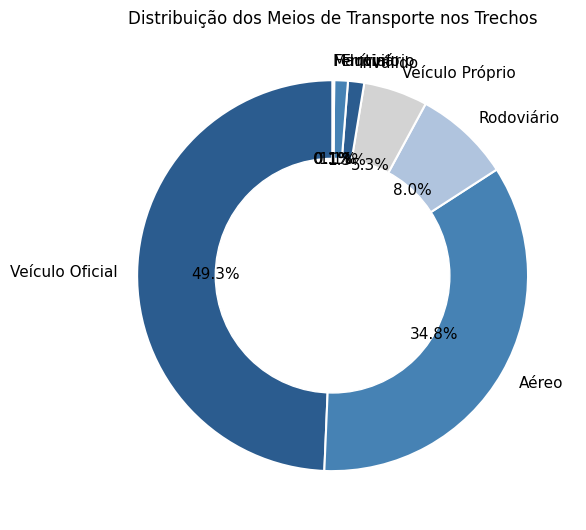

In [12]:
df_transporte_valido = df_trecho[~df_trecho['meio_transporte'].isin([None, 'Sem informação', ''])]
q5 = df_transporte_valido['meio_transporte'].value_counts().reset_index()
q5.columns = ['meio_transporte', 'quantidade']

print("=== P5: MEIO DE TRANSPORTE MAIS USADO NOS TRECHOS ===")
for idx, row in enumerate(q5.itertuples(), 1):
    print(f"{idx}. {row.meio_transporte:<20} | {row.quantidade:,} trechos")

plt.figure(figsize=(6, 6))
plt.pie(
    q5['quantidade'], 
    labels=q5['meio_transporte'], 
    autopct='%1.1f%%', 
    startangle=90, 
    colors=['#2b5c8f', '#4682b4', '#b0c4de', '#d3d3d3'],
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
circulo_centro = plt.Circle((0,0), 0.60, fc='white')
plt.gcf().gca().add_artist(circulo_centro)
plt.title("Distribuição dos Meios de Transporte nos Trechos")
plt.tight_layout()
plt.savefig("gold_p5_meio_transporte.png", dpi=300)
plt.show()

#### **P6. Qual UF de destino aparece em mais trechos?**

In [13]:
df_uf_valida = df_trecho[~df_trecho['destino_uf'].isin([None, 'Sem informação', ''])]

print("=== P6: UF DE DESTINO MAIS FREQUENTE NOS TRECHOS ===")
if not df_uf_valida.empty:
    q6 = df_uf_valida['destino_uf'].value_counts().reset_index()
    q6.columns = ['uf_destino', 'total_trechos']
    top_uf = q6.iloc[0]
    print(f"• UF de Destino: {top_uf['uf_destino']}")
    print(f"• Ocorrências:   {top_uf['total_trechos']:,} trechos")
else:
    print("[!] Nenhum trecho com UF de destino válida cadastrado.")

=== P6: UF DE DESTINO MAIS FREQUENTE NOS TRECHOS ===
• UF de Destino: Distrito Federal
• Ocorrências:   34,962 trechos


#### **P7. Qual órgão pagou mais no total?**

In [14]:
df_pagador_valido = df_pagamento[~df_pagamento['nome_orgao_pagador'].isin([None, 'Sem informação', ''])]
q7 = df_pagador_valido.groupby('nome_orgao_pagador')['valor'].sum().reset_index()

print("=== P7: ÓRGÃO COM MAIOR GASTO EM PAGAMENTOS CONSOLIDADOS ===")
if not q7.empty:
    top_q7 = q7.sort_values(by='valor', ascending=False).iloc[0]
    print(f"• Órgão Pagador:   {top_q7['nome_orgao_pagador']}")
    print(f"• Total Pago:      R$ {top_q7['valor']:,.2f}")
else:
    print("[!] Sem dados ou apenas 'Sem informação' listado na tabela de pagamentos.")

=== P7: ÓRGÃO COM MAIOR GASTO EM PAGAMENTOS CONSOLIDADOS ===
[!] Sem dados ou apenas 'Sem informação' listado na tabela de pagamentos.


---
### 🎨 3. Dashboard Executivo Interativo (Tema Escuro - Estilo Power BI)
Utilize o seletor dropdown para filtrar dinamicamente todos os dados e gráficos interativos no próprio corpo do notebook.

In [ ]:
TEMA_DARK = "plotly_dark"
COR_PRINCIPAL = "#2ecc71"  # Verde Neon clássico do Power BI

def renderizar_dashboard_interativo(orgao_selecionado="Todos"):
    df_filtrado = df_viagem.copy()
    if orgao_selecionado != "Todos":
        df_filtrado = df_filtrado[df_filtrado['nome_orgao_superior'] == orgao_selecionado]
        
    custo_total = df_filtrado['valor_total'].sum()
    qtd_viagens = len(df_filtrado)
    duracao_media = df_filtrado['duracao_dias'].mean() if len(df_filtrado) > 0 else 0
    
    if orgao_selecionado == "Todos":
        total_pago = df_pagamento['valor'].sum()
    else:
        ids_viagem_filtradas = set(df_filtrado['id_viagem'])
        total_pago = df_pagamento[df_pagamento['id_viagem'].isin(ids_viagem_filtradas)]['valor'].sum()

    html_kpis = f"""
    <div style="background-color: #111; padding: 20px; border-radius: 10px; margin-bottom: 20px; font-family: sans-serif;">
        <h2 style="color: white; margin-top: 0; text-align: center; border-bottom: 2px solid {COR_PRINCIPAL}; padding-bottom: 10px;">
            ✈️ Portal da Transparência: Painel Analítico de Viagens
        </h2>
        <div style="display: flex; justify-content: space-around; text-align: center; margin-top: 15px;">
            <div style="flex: 1;">
                <span style="color: #888; font-size: 13px; text-transform: uppercase;">Custo Total</span><br>
                <strong style="color: white; font-size: 22px;">R$ {custo_total:,.2f}</strong>
            </div>
            <div style="flex: 1; border-left: 1px solid #333;">
                <span style="color: #888; font-size: 13px; text-transform: uppercase;">Qtd. de Viagens</span><br>
                <strong style="color: white; font-size: 22px;">{qtd_viagens:,}</strong>
            </div>
            <div style="flex: 1; border-left: 1px solid #333;">
                <span style="color: #888; font-size: 13px; text-transform: uppercase;">Total Pago</span><br>
                <strong style="color: white; font-size: 22px;">R$ {total_pago:,.2f}</strong>
            </div>
            <div style="flex: 1; border-left: 1px solid #333;">
                <span style="color: #888; font-size: 13px; text-transform: uppercase;">Duração Média</span><br>
                <strong style="color: {COR_PRINCIPAL}; font-size: 22px;">{duracao_media:.1f} dias</strong>
            </div>
        </div>
    </div>
    """
    display(widgets.HTML(html_kpis))

    fig = make_subplots(
        rows=1, cols=2, 
        column_widths=[0.45, 0.55],
        subplot_titles=("Ranking: Órgãos por Custo", "Custo Total por Mês")
    )

    g1_data = df_filtrado.groupby('nome_orgao_superior')['valor_total'].sum().reset_index()
    g1_data = g1_data.sort_values(by='valor_total', ascending=False).head(5)
    
    fig.add_trace(
        go.Bar(
            x=g1_data['valor_total'],
            y=g1_data['nome_orgao_superior'],
            orientation='h',
            marker_color=COR_PRINCIPAL,
            text=[f"R$ {val/1e6:.1f}M" for val in g1_data['valor_total']],
            textposition='auto',
            name="Custo Total"
        ),
        row=1, col=1
    )

    df_filtrado['mes_ano'] = pd.to_datetime(df_filtrado['data_inicio'], errors='coerce').dt.to_period('M').astype(str)
    g2_data = df_filtrado[df_filtrado['mes_ano'] != 'NaT'].groupby('mes_ano')['valor_total'].sum().reset_index()
    g2_data = g2_data.sort_values(by='mes_ano')

    fig.add_trace(
        go.Scatter(
            x=g2_data['mes_ano'],
            y=g2_data['valor_total'],
            mode='lines+markers',
            line=dict(color=COR_PRINCIPAL, width=3),
            marker=dict(size=8),
            name="Evolução Mensal"
        ),
        row=1, col=2
    )

    fig.update_layout(
        template=TEMA_DARK,
        height=450,
        showlegend=False,
        paper_bgcolor="#111",
        plot_bgcolor="#111",
        margin=dict(l=20, r=20, t=40, b=20)
    )
    
    fig.update_yaxes(autorange="reversed", row=1, col=1)
    fig.show()

lista_orgaos = ["Todos"] + sorted(df_viagem['nome_orgao_superior'].dropna().unique().tolist())

interact(
    renderizar_dashboard_interativo, 
    orgao_selecionado=widgets.Dropdown(
        options=lista_orgaos, 
        value="Todos", 
        description="Filtro Órgão:",
        style={'description_width': 'initial'},
        layout={'width': '400px'}
    )
);

---
### 🏛️ 4. Camada Gold Agregada (Persistência no PostgreSQL)

In [ ]:
print("[*] Processando agregação para a camada Gold agregada...")

df_gold_agregada = df_viagem.groupby('nome_orgao_superior').agg(
    total_viagens=('id_viagem', 'count'),
    custo_total=('valor_total', 'sum'),
    custo_medio=('valor_total', 'mean'),
    duracao_media_dias=('duracao_dias', 'mean')
).reset_index()

df_gold_agregada['custo_medio'] = df_gold_agregada['custo_medio'].round(2)
df_gold_agregada['duracao_media_dias'] = df_gold_agregada['duracao_media_dias'].round(1)

# Tratamento estrito de valores nulos matemáticos antes de persistir no Postgres
df_gold_agregada = df_gold_agregada.where(pd.notnull(df_gold_agregada), None)

conexao = conectar()

sql_ddl = """
DROP TABLE IF EXISTS gold_resumo_orgaos CASCADE;
CREATE TABLE gold_resumo_orgaos (
    nome_orgao_superior VARCHAR(255) PRIMARY KEY,
    total_viagens INT,
    custo_total DECIMAL(14,2),
    custo_medio DECIMAL(12,2),
    duracao_media_dias DECIMAL(5,1)
);
"""
executar(conexao, sql_ddl)

colunas = ['nome_orgao_superior', 'total_viagens', 'custo_total', 'custo_medio', 'duracao_media_dias']
placeholders = ", ".join(["%s"] * len(colunas))
sql_insert = f"INSERT INTO gold_resumo_orgaos ({', '.join(colunas)}) VALUES ({placeholders})"

registros = [tuple(x) for x in df_gold_agregada.itertuples(index=False, name=None)]
inserir_em_lote(conexao, sql_insert, registros)

# SALVAMENTO FÍSICO COM COMMIT
conexao.commit()
conexao.close()

print(f"[SUCCESS] Tabela 'gold_resumo_orgaos' gravada com sucesso!")
print(f"  • {len(df_gold_agregada)} órgãos persistidos na camada Gold.")

---
### 🔎 5. Validação e Consulta Direta da Camada Gold

In [ ]:
print("[*] Conectando ao banco de dados para validar a tabela 'gold_resumo_orgaos'...")

conexao = conectar()
query_validacao = """
    SELECT 
        nome_orgao_superior, 
        total_viagens, 
        custo_total, 
        custo_medio, 
        duracao_media_dias
    FROM gold_resumo_orgaos
    ORDER BY custo_total DESC
    LIMIT 10;
"""
df_gold_verificacao = pd.read_sql_query(query_validacao, conexao)
conexao.close()

print(f"[+] Consulta de auditoria concluída com sucesso!")
print(f"  • Exibindo os 10 órgãos de maior relevância orçamentária persistidos na base:")
display(df_gold_verificacao)